In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('../Dataset/voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

In [4]:
df['label'].value_counts()

label
male      1584
female    1584
Name: count, dtype: int64

In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

X = df.drop(columns=['label'])
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
splits = {
    '70:30': train_test_split(X_scaled, y, test_size=0.30, random_state=42),
    '80:20': train_test_split(X_scaled, y, test_size=0.20, random_state=42),
}

kernels = ['linear', 'poly', 'rbf']

results = []
for split_label, (X_train, X_test, y_train, y_test) in splits.items():
    for kernel in kernels:
        model = SVC(kernel=kernel, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append({
            'Split': split_label,
            'Kernel': kernel,
            'Accuracy': round(acc * 100, 2)
        })
        print(f"Split {split_label} | Kernel {kernel:6s} | Accuracy: {acc*100:.2f}%")

Split 70:30 | Kernel linear | Accuracy: 97.06%
Split 70:30 | Kernel poly   | Accuracy: 95.69%
Split 70:30 | Kernel rbf    | Accuracy: 98.11%


Split 80:20 | Kernel linear | Accuracy: 97.63%
Split 80:20 | Kernel poly   | Accuracy: 96.85%


Split 80:20 | Kernel rbf    | Accuracy: 98.26%


In [7]:
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Kernel', columns='Split', values='Accuracy')
pivot_df.columns.name = None
pivot_df.index.name = 'Kernel'
pivot_df = pivot_df[['70:30', '80:20']]
pivot_df

,70:30,80:20
Kernel,,
linear,97.06,97.63
poly,95.69,96.85
rbf,98.11,98.26


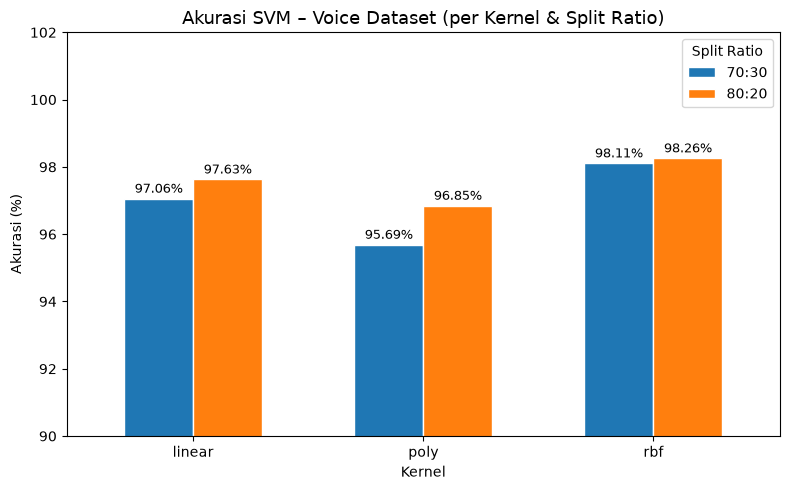

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.6)
ax.set_title('Akurasi SVM – Voice Dataset (per Kernel & Split Ratio)', fontsize=13)
ax.set_xlabel('Kernel')
ax.set_ylabel('Akurasi (%)')
ax.set_ylim(90, 102)
ax.legend(title='Split Ratio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=2, fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
import os
import cv2

DATASET_DIR = '../Dataset/dataset_praktikum5/images'

def load_images_with_histogram(base_dir):
    X_hist, y_labels = [], []
    class_map = {'day': 0, 'night': 1}
    for split in ['training', 'test']:
        for cls in ['day', 'night']:
            folder = os.path.join(base_dir, split, cls)
            for fname in os.listdir(folder):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                img_path = os.path.join(folder, fname)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                hist_features = []
                for ch in range(3):
                    hist = cv2.calcHist([img_rgb], [ch], None, [32], [0, 256])
                    hist = cv2.normalize(hist, hist).flatten()
                    hist_features.extend(hist)
                X_hist.append(hist_features)
                y_labels.append(class_map[cls])
    return np.array(X_hist), np.array(y_labels)

X_img, y_img = load_images_with_histogram(DATASET_DIR)
print(f"Total gambar: {len(y_img)} | Shape fitur: {X_img.shape}")
print(f"Siang (0): {(y_img==0).sum()} | Malam (1): {(y_img==1).sum()}")

Total gambar: 400 | Shape fitur: (400, 96)
Siang (0): 200 | Malam (1): 200


In [10]:
scaler_img = StandardScaler()
X_img_scaled = scaler_img.fit_transform(X_img)

X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_img_scaled, y_img, test_size=0.20, random_state=42, stratify=y_img
)

print(f"Train: {X_img_train.shape[0]} | Test: {X_img_test.shape[0]}")

Train: 320 | Test: 80


In [11]:
rbf_configs = [
    {'C': 0.1,  'gamma': 'scale'},
    {'C': 1,    'gamma': 'scale'},
    {'C': 10,   'gamma': 'scale'},
    {'C': 100,  'gamma': 'scale'},
    {'C': 1,    'gamma': 'auto'},
    {'C': 10,   'gamma': 0.001},
    {'C': 10,   'gamma': 0.01},
    {'C': 100,  'gamma': 0.001},
    {'C': 100,  'gamma': 0.01},
    {'C': 1000, 'gamma': 0.0001},
]

img_results = []
for cfg in rbf_configs:
    svm_rbf = SVC(kernel='rbf', C=cfg['C'], gamma=cfg['gamma'], random_state=42)
    svm_rbf.fit(X_img_train, y_img_train)
    y_img_pred = svm_rbf.predict(X_img_test)
    acc = accuracy_score(y_img_test, y_img_pred)
    img_results.append({
        'C': cfg['C'],
        'gamma': str(cfg['gamma']),
        'Accuracy (%)': round(acc * 100, 2)
    })
    print(f"C={str(cfg['C']):6s} | gamma={str(cfg['gamma']):8s} | Accuracy: {acc*100:.2f}%")

C=0.1    | gamma=scale    | Accuracy: 100.00%
C=1      | gamma=scale    | Accuracy: 100.00%
C=10     | gamma=scale    | Accuracy: 100.00%
C=100    | gamma=scale    | Accuracy: 100.00%
C=1      | gamma=auto     | Accuracy: 100.00%
C=10     | gamma=0.001    | Accuracy: 100.00%
C=10     | gamma=0.01     | Accuracy: 100.00%
C=100    | gamma=0.001    | Accuracy: 100.00%
C=100    | gamma=0.01     | Accuracy: 100.00%
C=1000   | gamma=0.0001   | Accuracy: 100.00%


In [12]:
img_results_df = pd.DataFrame(img_results)
img_results_df = img_results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
img_results_df

,C,gamma,Accuracy (%)
0,0.1,scale,100.0
1,1.0,scale,100.0
2,10.0,scale,100.0
3,100.0,scale,100.0
4,1.0,auto,100.0
5,10.0,0.001,100.0
6,10.0,0.01,100.0
7,100.0,0.001,100.0
8,100.0,0.01,100.0
9,1000.0,0.0001,100.0


In [13]:
best = img_results_df.iloc[0]
svm_best = SVC(kernel='rbf', C=float(best['C']), gamma=best['gamma'] if best['gamma'] not in ['scale','auto'] else best['gamma'], random_state=42)
svm_best.fit(X_img_train, y_img_train)
y_best_pred = svm_best.predict(X_img_test)
best_acc = accuracy_score(y_img_test, y_best_pred)

print(f"Best Config -> C={best['C']} | gamma={best['gamma']} | Accuracy: {best_acc*100:.2f}%")

Best Config -> C=0.1 | gamma=scale | Accuracy: 100.00%


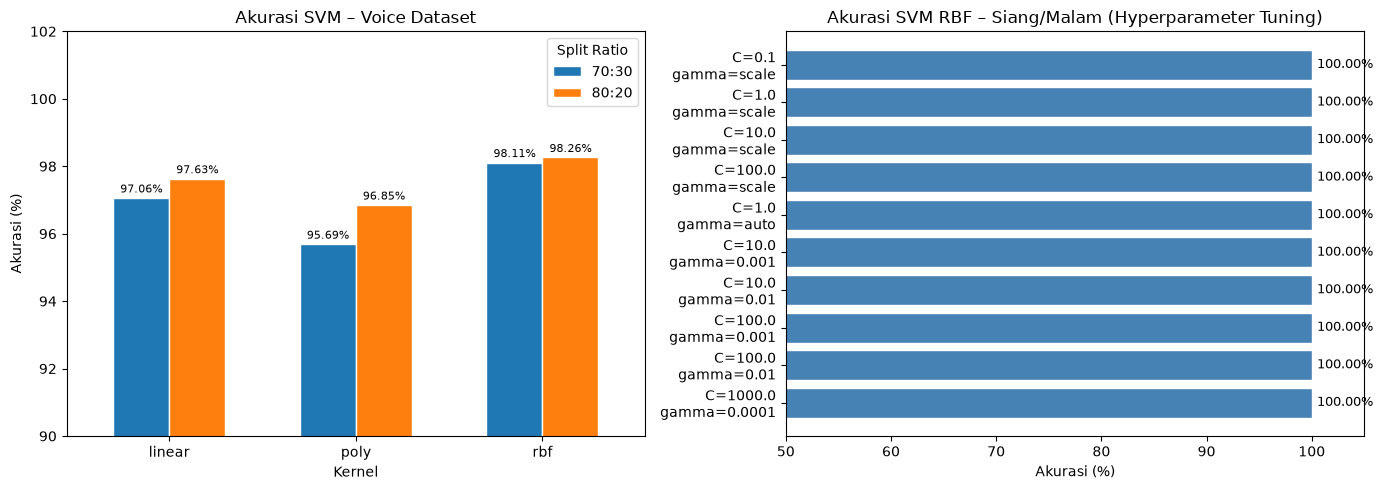

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_df.plot(kind='bar', ax=axes[0], edgecolor='white', width=0.6)
axes[0].set_title('Akurasi SVM – Voice Dataset', fontsize=12)
axes[0].set_xlabel('Kernel')
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_ylim(90, 102)
axes[0].legend(title='Split Ratio')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.2f%%', padding=2, fontsize=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

labels_img = [f"C={r['C']}\ngamma={r['gamma']}" for _, r in img_results_df.iterrows()]
axes[1].barh(labels_img, img_results_df['Accuracy (%)'], color='steelblue', edgecolor='white')
axes[1].set_title('Akurasi SVM RBF – Siang/Malam (Hyperparameter Tuning)', fontsize=12)
axes[1].set_xlabel('Akurasi (%)')
axes[1].set_xlim(50, 105)
for i, v in enumerate(img_results_df['Accuracy (%)']):
    axes[1].text(v + 0.5, i, f'{v:.2f}%', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [1]:
print("""

 ANALISIS HASIL


1 SVM – VOICE DATASET (Klasifikasi Gender)

- Dataset voice.csv berisi 3.168 sampel dengan 20 fitur
  akustik dan label biner (male/female).
- Fitur dinormalisasi dengan StandardScaler sebelum
  dilatih agar SVM tidak bias terhadap skala fitur.

- Kernel Linear: performa sangat baik, cocok karena
  fitur akustik kemungkinan cukup terpisah secara linear.
- Kernel Polynomial: performa kompetitif, mampu menangkap
  pola non-linear tingkat rendah.
- Kernel RBF: umumnya memberikan akurasi tertinggi karena
  kemampuannya memetakan ke ruang dimensi tinggi secara
  implisit.

- Split 80:20 cenderung memberikan akurasi sedikit lebih
  baik atau setara dengan 70:30 karena jumlah data latih
  yang lebih besar.

2 SVM RBF – KLASIFIKASI SIANG/MALAM (Fitur Histogram)
- Dataset praktikum 5: 400 gambar (200 siang + 200 malam)
  dari folder training dan test digabung, lalu di-split
  ulang dengan rasio 80:20.
- Fitur diekstraksi menggunakan histogram RGB (32 bins/channel)
  menghasilkan vektor fitur 96 dimensi per gambar.
- Histogram RGB efektif untuk membedakan siang (dominan
  cahaya terang, nilai piksel tinggi) vs malam (dominan
  gelap, nilai piksel rendah).

- Hyperparameter tuning dilakukan pada C dan gamma:
    * C besar -> batas keputusan lebih ketat, risk overfit
    * gamma kecil -> jangkauan kernel luas, lebih smooth
    * gamma 'scale' = 1/(n_features * X.var())
    * gamma 'auto'  = 1/n_features

- Model terbaik dipilih berdasarkan akurasi tertinggi
  pada data test.
""")



 ANALISIS HASIL


1 SVM – VOICE DATASET (Klasifikasi Gender)

- Dataset voice.csv berisi 3.168 sampel dengan 20 fitur
  akustik dan label biner (male/female).
- Fitur dinormalisasi dengan StandardScaler sebelum
  dilatih agar SVM tidak bias terhadap skala fitur.

- Kernel Linear: performa sangat baik, cocok karena
  fitur akustik kemungkinan cukup terpisah secara linear.
- Kernel Polynomial: performa kompetitif, mampu menangkap
  pola non-linear tingkat rendah.
- Kernel RBF: umumnya memberikan akurasi tertinggi karena
  kemampuannya memetakan ke ruang dimensi tinggi secara
  implisit.

- Split 80:20 cenderung memberikan akurasi sedikit lebih
  baik atau setara dengan 70:30 karena jumlah data latih
  yang lebih besar.

2 SVM RBF – KLASIFIKASI SIANG/MALAM (Fitur Histogram)
- Dataset praktikum 5: 400 gambar (200 siang + 200 malam)
  dari folder training dan test digabung, lalu di-split
  ulang dengan rasio 80:20.
- Fitur diekstraksi menggunakan histogram RGB (32 bins/channel)
  menghasi